Multiple files found for combined_clustered_data_1462_k5.csv. Using first:
   c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\copy_pseudotime_highres_confinement_scan\datasets\combined_clustered_data_1462_k5.csv
   c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\copy_pseudotime_highres_confinement_scan\datasets\Figure_12_GIF\combined_clustered_data_1462_k5.csv
   c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\copy_pseudotime_highres_confinement_scan\datasets\for Danya ML\old\combined_clustered_data_1462_k5.csv
   c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\datasets\Figure_12_GIF\combined_clustered_data_1462_k5.csv
   c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\datasets\for Danya ML\old\combined_clustered_data_1462_k5.csv
Using 1462 CSV: c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\copy_pseudotime_highres_confinement_scan\datasets\combined_clustered_data_1462_k5.csv
Using 1476 CSV: 

,selected_id,Metadata_ObjNumber,dapi_Number_Object_Number,dapi_ImageNumber,ObjectNumber
selected_id,,,,,
2870001,2870001,287,1,159,1
4630001,4630001,463,1,269,1



Selected feature 1476 rows:


,selected_id,Metadata_ObjNumber,dapi_Number_Object_Number,dapi_ImageNumber,ObjectNumber
selected_id,,,,,
5170001,5170001,517,1,439,1
4680001,4680001,468,1,393,1


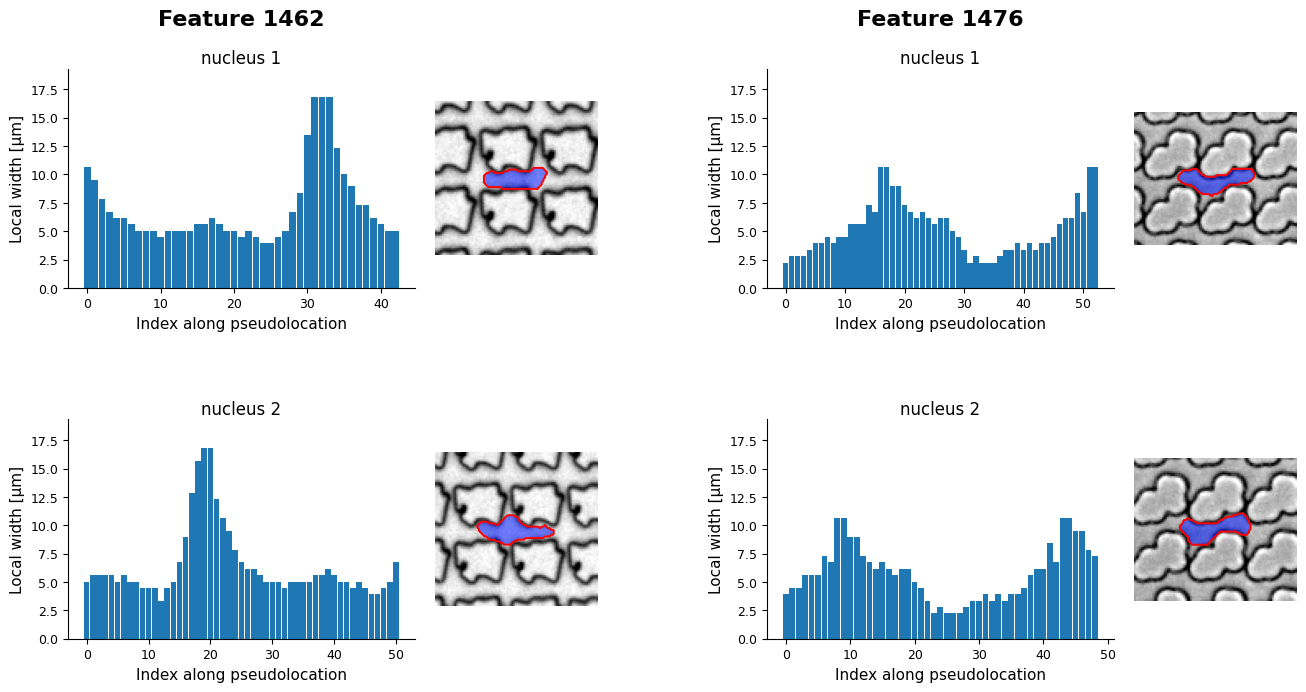

Saved PNG: Figure4_pseudolocation_fingerprints_clean.png
Saved PDF: Figure4_pseudolocation_fingerprints_clean.pdf


In [15]:
# ============================================================
# Figure 4: pseudolocation fingerprints
# Cleaner stitched layout
# selected_id = Metadata_ObjNumber * 10000 + dapi_Number_Object_Number
# ============================================================

import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import transform, filters, morphology, measure
from skimage.io import imread


# ============================================================
# Settings
# ============================================================

PIXEL_SIZE_UM = 0.56

FEATURE_1462_IDS = [2870001, 4630001]
FEATURE_1476_IDS = [5170001, 4680001]

FEATURE_ROTATION_DEG = {
    1462: 28.34,
    1476: -13.47,
}

OUT_PNG = "Figure4_pseudolocation_fingerprints_clean.png"
OUT_PDF = "Figure4_pseudolocation_fingerprints_clean.pdf"

CSV_1462_NAME = "combined_clustered_data_1462_k5.csv"
CSV_1476_NAME = "combined_clustered_data_1476_k3.csv"

ROOT = Path.cwd()


# ============================================================
# Load CSVs
# ============================================================

def find_file(root, filename):
    matches = list(root.rglob(filename))
    if len(matches) == 0:
        raise FileNotFoundError(f"Could not find {filename} under:\n{root}")
    if len(matches) > 1:
        print(f"Multiple files found for {filename}. Using first:")
        for m in matches:
            print("  ", m)
    return matches[0]


csv_1462 = find_file(ROOT, CSV_1462_NAME)
csv_1476 = find_file(ROOT, CSV_1476_NAME)

print("Using 1462 CSV:", csv_1462)
print("Using 1476 CSV:", csv_1476)

df1462 = pd.read_csv(csv_1462)
df1476 = pd.read_csv(csv_1476)

print("df1462:", df1462.shape)
print("df1476:", df1476.shape)


# ============================================================
# Helpers
# ============================================================

def parse_array(x, dtype=float):
    if x is None:
        return np.array([], dtype=dtype)

    if isinstance(x, np.ndarray):
        return x.astype(dtype)

    if isinstance(x, (list, tuple)):
        return np.asarray(x, dtype=dtype)

    if isinstance(x, str):
        s = x.strip()

        if s == "" or s.lower() == "nan":
            return np.array([], dtype=dtype)

        s = s.replace("array(", "").rstrip(")")

        try:
            return np.asarray(ast.literal_eval(s), dtype=dtype)
        except Exception:
            s = (
                s.replace("\n", " ")
                 .replace(",", " ")
                 .replace("[", " ")
                 .replace("]", " ")
                 .strip()
            )
            if s == "":
                return np.array([], dtype=dtype)
            return np.fromstring(s, sep=" ", dtype=dtype)

    try:
        if pd.isna(x):
            return np.array([], dtype=dtype)
    except Exception:
        pass

    return np.asarray(x, dtype=dtype)


def normalize_percentile(img, pmin=1, pmax=99):
    img = np.asarray(img, dtype=float)
    lo, hi = np.nanpercentile(img, [pmin, pmax])

    if hi <= lo:
        return np.zeros_like(img, dtype=float)

    return np.clip((img - lo) / (hi - lo), 0, 1)


def to_2d_image(img):
    img = np.asarray(img)
    img = np.squeeze(img)

    if img.ndim == 2:
        return img.astype(float)

    if img.ndim == 3:
        if img.shape[0] <= 4:
            return img[0].astype(float)
        if img.shape[-1] <= 4:
            return img[..., 0].astype(float)
        return img[0].astype(float)

    if img.ndim == 4:
        return np.squeeze(img[0, 0]).astype(float)

    raise ValueError(f"Unsupported image shape: {img.shape}")


def read_image(path_value):
    path = Path(str(path_value))
    if not path.exists():
        raise FileNotFoundError(
            f"Image path does not exist:\n{path}\n\n"
            "The CSV likely contains absolute paths. Please run on the same machine "
            "or update the paths."
        )
    return to_2d_image(imread(path))


def rotate_keep_shape(img, angle_deg):
    return transform.rotate(
        img,
        angle=angle_deg,
        resize=False,
        preserve_range=True,
        mode="constant",
        cval=0,
        order=1,
    ).astype(float)


# ============================================================
# Select nuclei
# ============================================================

def add_selected_id(df):
    """
    selected_id = Metadata_ObjNumber * 10000 + dapi_Number_Object_Number
    """
    df = df.copy()

    for col in ["Metadata_ObjNumber", "dapi_Number_Object_Number"]:
        if col not in df.columns:
            raise KeyError(f"Missing required column: {col}")

    meta = pd.to_numeric(df["Metadata_ObjNumber"], errors="coerce")
    obj = pd.to_numeric(df["dapi_Number_Object_Number"], errors="coerce")

    df["selected_id"] = meta * 10000 + obj
    df = df.dropna(subset=["selected_id"])
    df["selected_id"] = df["selected_id"].astype(int)

    return df


def select_examples(df, ids, feature_id):
    df = add_selected_id(df)

    ids = [int(i) for i in ids]
    available = set(df["selected_id"])

    missing = [i for i in ids if i not in available]
    if missing:
        raise KeyError(f"Feature {feature_id}: could not find selected IDs {missing}")

    selected = df.set_index("selected_id", drop=False).loc[ids].copy()

    print(f"\nSelected feature {feature_id} rows:")
    cols = [
        "selected_id",
        "Metadata_ObjNumber",
        "dapi_Number_Object_Number",
        "dapi_ImageNumber",
        "ObjectNumber",
    ]
    cols = [c for c in cols if c in selected.columns]
    display(selected[cols])

    return selected


# ============================================================
# Crop and inset
# ============================================================

def get_rotated_bbox_abs(row, image_shape):
    H, W = image_shape[:2]
    cx0 = (W - 1) / 2
    cy0 = (H - 1) / 2

    x_min = float(row["bbox_rot_min_x"]) + cx0
    x_max = float(row["bbox_rot_max_x"]) + cx0
    y_min = float(row["bbox_rot_min_y"]) + cy0
    y_max = float(row["bbox_rot_max_y"]) + cy0

    return x_min, x_max, y_min, y_max


def crop_nucleus_region(row, feature_id, pad=25):
    bg = read_image(row["path_background"])
    dapi = read_image(row["path_dapi"])

    if dapi.shape != bg.shape:
        dapi = transform.resize(
            dapi,
            bg.shape,
            preserve_range=True,
            anti_aliasing=True
        ).astype(float)

    angle = FEATURE_ROTATION_DEG[int(feature_id)]

    bg_rot = rotate_keep_shape(bg, angle)
    dapi_rot = rotate_keep_shape(dapi, angle)

    x_min, x_max, y_min, y_max = get_rotated_bbox_abs(row, bg_rot.shape)

    H, W = bg_rot.shape[:2]

    x0 = max(int(np.floor(x_min)) - pad, 0)
    x1 = min(int(np.ceil(x_max)) + pad, W)
    y0 = max(int(np.floor(y_min)) - pad, 0)
    y1 = min(int(np.ceil(y_max)) + pad, H)

    bg_crop = bg_rot[y0:y1, x0:x1]
    dapi_crop = dapi_rot[y0:y1, x0:x1]

    return bg_crop, dapi_crop


def segment_dapi_crop(dapi_crop):
    dapi_n = normalize_percentile(dapi_crop, 1, 99)
    dapi_s = filters.gaussian(dapi_n, sigma=0.7)

    positive = dapi_s[dapi_s > 0]
    if positive.size < 10:
        return np.zeros_like(dapi_s, dtype=bool)

    try:
        thr = filters.threshold_otsu(positive)
    except Exception:
        thr = positive.mean() + positive.std()

    mask = dapi_s > thr
    mask = morphology.remove_small_objects(mask, min_size=15)
    mask = morphology.binary_closing(mask, morphology.disk(1))

    lab = measure.label(mask)
    props = measure.regionprops(lab)

    if len(props) == 0:
        return mask

    H, W = mask.shape
    center = np.array([H / 2, W / 2])

    def score(prop):
        cy, cx = prop.centroid
        dist = np.linalg.norm(np.array([cy, cx]) - center)
        return dist - 0.02 * prop.area

    best = min(props, key=score)
    return lab == best.label


def make_inset_rgb(bg_crop, dapi_crop):
    bg_n = normalize_percentile(bg_crop, 1, 99)
    dapi_mask = segment_dapi_crop(dapi_crop)

    rgb = np.dstack([bg_n, bg_n, bg_n])

    alpha = 0.55
    rgb[dapi_mask, 0] = (1 - alpha) * rgb[dapi_mask, 0]
    rgb[dapi_mask, 1] = (1 - alpha) * rgb[dapi_mask, 1] + alpha * 0.10
    rgb[dapi_mask, 2] = (1 - alpha) * rgb[dapi_mask, 2] + alpha * 1.00

    return np.clip(rgb, 0, 1), dapi_mask


def plot_inset(ax, row, feature_id, pad=25):
    bg_crop, dapi_crop = crop_nucleus_region(row, feature_id=feature_id, pad=pad)
    rgb, dapi_mask = make_inset_rgb(bg_crop, dapi_crop)

    ax.imshow(rgb)
    contours = measure.find_contours(dapi_mask.astype(float), 0.5)
    for contour in contours:
        ax.plot(contour[:, 1], contour[:, 0], color="red", linewidth=1.4)

    ax.set_aspect("equal")
    ax.axis("off")


# ============================================================
# Bar plot
# ============================================================

def plot_width_profile(ax, row, title, show_ylabel=True):
    widths_px = parse_array(row["pseudotime_widths"], dtype=float)
    widths_um = widths_px * PIXEL_SIZE_UM

    x = np.arange(len(widths_um))
    ax.bar(x, widths_um, width=0.9)

    ax.set_title(title, fontsize=12, pad=4)
    ax.set_xlabel("Index along pseudolocation", fontsize=11)

    if show_ylabel:
        ax.set_ylabel("Local width [µm]", fontsize=11)
    else:
        ax.set_ylabel("")

    ax.tick_params(axis="both", labelsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return widths_um


# ============================================================
# Main figure
# ============================================================

def plot_figure4_pseudolocation_fingerprints(
    df1462,
    df1476,
    save_png=OUT_PNG,
    save_pdf=OUT_PDF,
    dpi=300,
):
    df1462_examples = select_examples(df1462, FEATURE_1462_IDS, feature_id=1462)
    df1476_examples = select_examples(df1476, FEATURE_1476_IDS, feature_id=1476)

    fig = plt.figure(figsize=(13.5, 7.5), constrained_layout=False)
    fig.patch.set_facecolor("white")

    # Outer grid: two feature blocks
    outer = fig.add_gridspec(
        1, 2,
        width_ratios=[1, 1],
        wspace=0.32
    )

    # Left feature block
    gs_left = outer[0].subgridspec(
        2, 2,
        width_ratios=[3.3, 1.55],
        hspace=0.6,
        wspace=0.08
    )

    # Right feature block
    gs_right = outer[1].subgridspec(
        2, 2,
        width_ratios=[3.3, 1.55],
        hspace=0.6,
        wspace=0.08
    )

    ax_1462_bar_1 = fig.add_subplot(gs_left[0, 0])
    ax_1462_img_1 = fig.add_subplot(gs_left[0, 1])
    ax_1462_bar_2 = fig.add_subplot(gs_left[1, 0])
    ax_1462_img_2 = fig.add_subplot(gs_left[1, 1])

    ax_1476_bar_1 = fig.add_subplot(gs_right[0, 0])
    ax_1476_img_1 = fig.add_subplot(gs_right[0, 1])
    ax_1476_bar_2 = fig.add_subplot(gs_right[1, 0])
    ax_1476_img_2 = fig.add_subplot(gs_right[1, 1])

    # Block titles
    ax_1462_bar_1.text(
        0.5, 1.18, "Feature 1462",
        transform=ax_1462_bar_1.transAxes,
        ha="center", va="bottom",
        fontsize=16, fontweight="bold"
    )

    ax_1476_bar_1.text(
        0.5, 1.18, "Feature 1476",
        transform=ax_1476_bar_1.transAxes,
        ha="center", va="bottom",
        fontsize=16, fontweight="bold"
    )

    # Left block
    w_1462_1 = plot_width_profile(ax_1462_bar_1, df1462_examples.iloc[0], "nucleus 1", show_ylabel=True)
    plot_inset(ax_1462_img_1, df1462_examples.iloc[0], feature_id=1462, pad=25)

    w_1462_2 = plot_width_profile(ax_1462_bar_2, df1462_examples.iloc[1], "nucleus 2", show_ylabel=True)
    plot_inset(ax_1462_img_2, df1462_examples.iloc[1], feature_id=1462, pad=25)

    # Right block
    w_1476_1 = plot_width_profile(ax_1476_bar_1, df1476_examples.iloc[0], "nucleus 1", show_ylabel=True)
    plot_inset(ax_1476_img_1, df1476_examples.iloc[0], feature_id=1476, pad=25)

    w_1476_2 = plot_width_profile(ax_1476_bar_2, df1476_examples.iloc[1], "nucleus 2", show_ylabel=True)
    plot_inset(ax_1476_img_2, df1476_examples.iloc[1], feature_id=1476, pad=25)

    # Shared y limit
    all_widths = np.concatenate([w_1462_1, w_1462_2, w_1476_1, w_1476_2])
    ymax = max(18, np.nanmax(all_widths) * 1.15)

    for ax in [ax_1462_bar_1, ax_1462_bar_2, ax_1476_bar_1, ax_1476_bar_2]:
        ax.set_ylim(0, ymax)

    # Better margins
    fig.subplots_adjust(
        left=0.07,
        right=0.98,
        top=0.88,
        bottom=0.12
    )

    fig.savefig(save_png, dpi=dpi, bbox_inches="tight", facecolor="white")
    fig.savefig(save_pdf, dpi=dpi, bbox_inches="tight", facecolor="white")

    plt.show()

    print(f"Saved PNG: {save_png}")
    print(f"Saved PDF: {save_pdf}")

    return fig


# ============================================================
# Run
# ============================================================

fig = plot_figure4_pseudolocation_fingerprints(
    df1462=df1462,
    df1476=df1476,
    save_png=OUT_PNG,
    save_pdf=OUT_PDF,
    dpi=300,
)

Multiple files found for combined_clustered_data_1462_k5.csv. Using first:
   c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\copy_pseudotime_highres_confinement_scan\datasets\combined_clustered_data_1462_k5.csv
   c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\copy_pseudotime_highres_confinement_scan\datasets\Figure_12_GIF\combined_clustered_data_1462_k5.csv
   c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\copy_pseudotime_highres_confinement_scan\datasets\for Danya ML\old\combined_clustered_data_1462_k5.csv
   c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\datasets\Figure_12_GIF\combined_clustered_data_1462_k5.csv
   c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\datasets\for Danya ML\old\combined_clustered_data_1462_k5.csv
Using 1462 CSV: c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\copy_pseudotime_highres_confinement_scan\datasets\combined_clustered_data_1462_k5.csv
Using 1476 CSV: 

,selected_id,Metadata_ObjNumber,dapi_Number_Object_Number,dapi_ImageNumber,ObjectNumber
selected_id,,,,,
2870001,2870001,287,1,159,1
4630001,4630001,463,1,269,1



Selected feature 1476 rows:


,selected_id,Metadata_ObjNumber,dapi_Number_Object_Number,dapi_ImageNumber,ObjectNumber
selected_id,,,,,
5170001,5170001,517,1,439,1
4680001,4680001,468,1,393,1


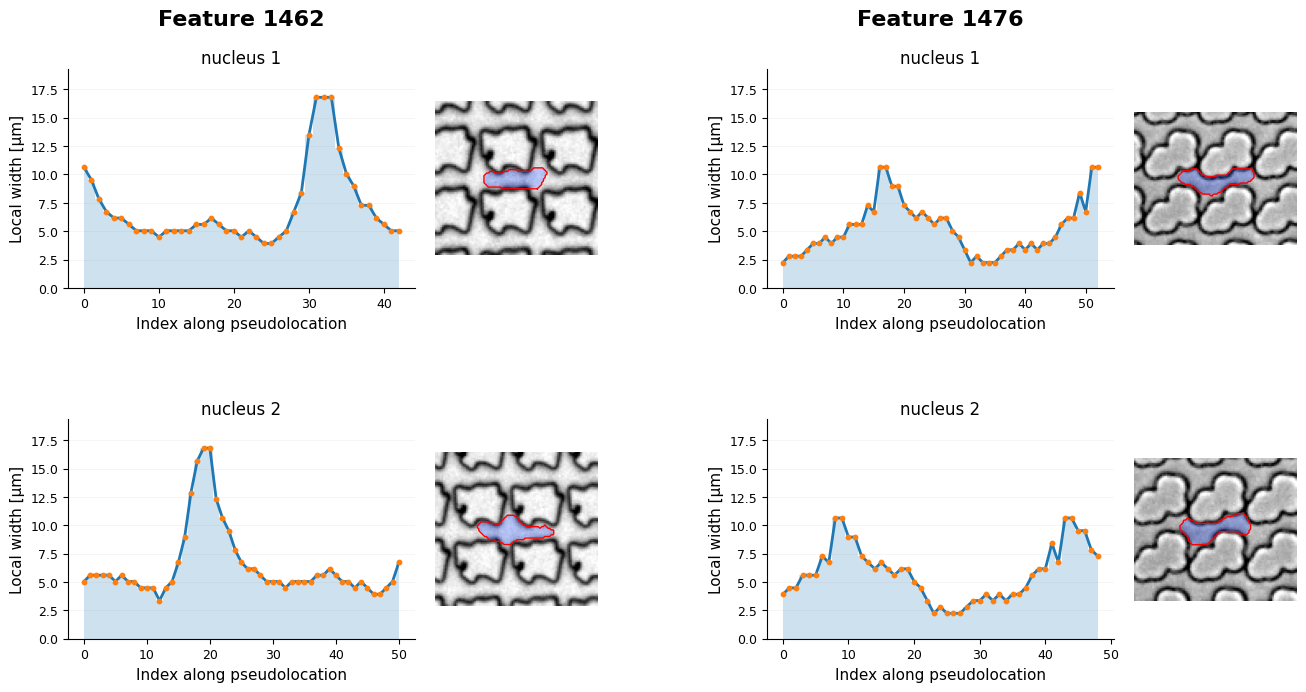

Saved PNG: Figure4_pseudolocation_fingerprints_clean_profile.png
Saved PDF: Figure4_pseudolocation_fingerprints_clean_profile.pdf


In [ ]:
# ============================================================
# Figure 4: pseudolocation fingerprints
# Cleaner profile style + cleaner inset overlay
#
# selected_id = Metadata_ObjNumber * 10000 + dapi_Number_Object_Number
# ============================================================

import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import transform, filters, morphology, measure
from skimage.io import imread


# ============================================================
# Settings
# ============================================================

PIXEL_SIZE_UM = 0.56

FEATURE_1462_IDS = [2870001, 4630001]
FEATURE_1476_IDS = [5170001, 4680001]

FEATURE_ROTATION_DEG = {
    1462: 28.34,
    1476: -13.47,
}

OUT_PNG = "Figure4_pseudolocation_fingerprints_clean_profile.png"
OUT_PDF = "Figure4_pseudolocation_fingerprints_clean_profile.pdf"

CSV_1462_NAME = "combined_clustered_data_1462_k5.csv"
CSV_1476_NAME = "combined_clustered_data_1476_k3.csv"

ROOT = Path.cwd()

INSET_PAD = 25
INSET_BLUE_ALPHA = 0.25
NUCLEUS_OUTLINE_WIDTH = 1.0

PROFILE_LINEWIDTH = 2.0
PROFILE_MARKER_SIZE = 10
PROFILE_FILL_ALPHA = 0.22


# ============================================================
# Load CSVs
# ============================================================

def find_file(root, filename):
    matches = list(root.rglob(filename))

    if len(matches) == 0:
        raise FileNotFoundError(f"Could not find {filename} under:\n{root}")

    if len(matches) > 1:
        print(f"Multiple files found for {filename}. Using first:")
        for m in matches:
            print("  ", m)

    return matches[0]


csv_1462 = find_file(ROOT, CSV_1462_NAME)
csv_1476 = find_file(ROOT, CSV_1476_NAME)

print("Using 1462 CSV:", csv_1462)
print("Using 1476 CSV:", csv_1476)

df1462 = pd.read_csv(csv_1462)
df1476 = pd.read_csv(csv_1476)

print("df1462:", df1462.shape)
print("df1476:", df1476.shape)


# ============================================================
# General helpers
# ============================================================

def parse_array(x, dtype=float):
    """
    Robust parser for list-like columns such as pseudotime_widths.
    """
    if x is None:
        return np.array([], dtype=dtype)

    if isinstance(x, np.ndarray):
        return x.astype(dtype)

    if isinstance(x, (list, tuple)):
        return np.asarray(x, dtype=dtype)

    if isinstance(x, str):
        s = x.strip()

        if s == "" or s.lower() == "nan":
            return np.array([], dtype=dtype)

        s = s.replace("array(", "").rstrip(")")

        try:
            return np.asarray(ast.literal_eval(s), dtype=dtype)
        except Exception:
            s = (
                s.replace("\n", " ")
                 .replace(",", " ")
                 .replace("[", " ")
                 .replace("]", " ")
                 .strip()
            )
            if s == "":
                return np.array([], dtype=dtype)

            return np.fromstring(s, sep=" ", dtype=dtype)

    try:
        if pd.isna(x):
            return np.array([], dtype=dtype)
    except Exception:
        pass

    return np.asarray(x, dtype=dtype)


def normalize_percentile(img, pmin=1, pmax=99):
    img = np.asarray(img, dtype=float)

    if img.size == 0:
        return img

    lo, hi = np.nanpercentile(img, [pmin, pmax])

    if hi <= lo:
        return np.zeros_like(img, dtype=float)

    return np.clip((img - lo) / (hi - lo), 0, 1)


def to_2d_image(img):
    img = np.asarray(img)
    img = np.squeeze(img)

    if img.ndim == 2:
        return img.astype(float)

    if img.ndim == 3:
        # channel-first
        if img.shape[0] <= 4:
            return img[0].astype(float)

        # channel-last
        if img.shape[-1] <= 4:
            return img[..., 0].astype(float)

        # z-stack / multipage
        return img[0].astype(float)

    if img.ndim == 4:
        return np.squeeze(img[0, 0]).astype(float)

    raise ValueError(f"Unsupported image shape: {img.shape}")


def read_image(path_value):
    path = Path(str(path_value))

    if not path.exists():
        raise FileNotFoundError(
            f"Image path does not exist:\n{path}\n\n"
            "The CSV probably contains absolute Windows paths. "
            "Run the notebook on the same computer or update the image paths."
        )

    return to_2d_image(imread(path))


def rotate_keep_shape(img, angle_deg):
    return transform.rotate(
        img,
        angle=angle_deg,
        resize=False,
        preserve_range=True,
        mode="constant",
        cval=0,
        order=1,
    ).astype(float)


# ============================================================
# Select nuclei
# ============================================================

def add_selected_id(df):
    """
    In these CSVs:
        selected_id = Metadata_ObjNumber * 10000 + dapi_Number_Object_Number

    Example:
        4630001 = Metadata_ObjNumber 463, object 1
    """
    df = df.copy()

    required_cols = ["Metadata_ObjNumber", "dapi_Number_Object_Number"]

    for col in required_cols:
        if col not in df.columns:
            raise KeyError(f"Missing required column: {col}")

    meta = pd.to_numeric(df["Metadata_ObjNumber"], errors="coerce")
    obj = pd.to_numeric(df["dapi_Number_Object_Number"], errors="coerce")

    df["selected_id"] = meta * 10000 + obj
    df = df.dropna(subset=["selected_id"])
    df["selected_id"] = df["selected_id"].astype(int)

    return df


def select_examples(df, ids, feature_id):
    df = add_selected_id(df)

    ids = [int(i) for i in ids]
    available = set(df["selected_id"])

    missing = [i for i in ids if i not in available]

    if missing:
        print(f"\nFeature {feature_id}: missing selected IDs:", missing)
        print("Available selected_id range:")
        print(df["selected_id"].min(), "to", df["selected_id"].max())

        raise KeyError(
            f"Feature {feature_id}: could not find selected IDs {missing}."
        )

    selected = df.set_index("selected_id", drop=False).loc[ids].copy()

    print(f"\nSelected feature {feature_id} rows:")

    cols = [
        "selected_id",
        "Metadata_ObjNumber",
        "dapi_Number_Object_Number",
        "dapi_ImageNumber",
        "ObjectNumber",
    ]
    cols = [c for c in cols if c in selected.columns]

    display(selected[cols])

    return selected


# ============================================================
# Image crop and overlay
# ============================================================

def get_rotated_bbox_abs(row, image_shape):
    """
    bbox_rot_* columns are stored relative to the image center.
    Convert them back to absolute image coordinates.
    """
    H, W = image_shape[:2]

    cx0 = (W - 1) / 2
    cy0 = (H - 1) / 2

    x_min = float(row["bbox_rot_min_x"]) + cx0
    x_max = float(row["bbox_rot_max_x"]) + cx0
    y_min = float(row["bbox_rot_min_y"]) + cy0
    y_max = float(row["bbox_rot_max_y"]) + cy0

    return x_min, x_max, y_min, y_max


def crop_nucleus_region(row, feature_id, pad=INSET_PAD):
    bg = read_image(row["path_background"])
    dapi = read_image(row["path_dapi"])

    if dapi.shape != bg.shape:
        dapi = transform.resize(
            dapi,
            bg.shape,
            preserve_range=True,
            anti_aliasing=True,
        ).astype(float)

    angle = FEATURE_ROTATION_DEG[int(feature_id)]

    bg_rot = rotate_keep_shape(bg, angle)
    dapi_rot = rotate_keep_shape(dapi, angle)

    x_min, x_max, y_min, y_max = get_rotated_bbox_abs(row, bg_rot.shape)

    H, W = bg_rot.shape[:2]

    x0 = max(int(np.floor(x_min)) - pad, 0)
    x1 = min(int(np.ceil(x_max)) + pad, W)
    y0 = max(int(np.floor(y_min)) - pad, 0)
    y1 = min(int(np.ceil(y_max)) + pad, H)

    bg_crop = bg_rot[y0:y1, x0:x1]
    dapi_crop = dapi_rot[y0:y1, x0:x1]

    return bg_crop, dapi_crop


def segment_dapi_crop(dapi_crop):
    """
    Makes a simple visual mask for the DAPI-positive nucleus.
    Keeps the connected component closest to the crop center.
    """
    dapi_n = normalize_percentile(dapi_crop, 1, 99)

    if dapi_n.size == 0:
        return np.zeros_like(dapi_n, dtype=bool)

    dapi_s = filters.gaussian(dapi_n, sigma=0.7)

    positive = dapi_s[dapi_s > 0]

    if positive.size < 10:
        return np.zeros_like(dapi_s, dtype=bool)

    try:
        thr = filters.threshold_otsu(positive)
    except Exception:
        thr = positive.mean() + positive.std()

    mask = dapi_s > thr
    mask = morphology.remove_small_objects(mask, min_size=15)
    mask = morphology.binary_closing(mask, morphology.disk(1))

    lab = measure.label(mask)
    props = measure.regionprops(lab)

    if len(props) == 0:
        return mask

    H, W = mask.shape
    center = np.array([H / 2, W / 2])

    def score(prop):
        cy, cx = prop.centroid
        dist = np.linalg.norm(np.array([cy, cx]) - center)
        return dist - 0.02 * prop.area

    best = min(props, key=score)

    return lab == best.label


def make_inset_rgb(bg_crop, dapi_crop):
    bg_n = normalize_percentile(bg_crop, 1, 99)
    dapi_mask = segment_dapi_crop(dapi_crop)

    rgb = np.dstack([bg_n, bg_n, bg_n])

    # Subtle blue fill for the nucleus
    alpha = INSET_BLUE_ALPHA
    rgb[dapi_mask, 0] = (1 - alpha) * rgb[dapi_mask, 0]
    rgb[dapi_mask, 1] = (1 - alpha) * rgb[dapi_mask, 1] + alpha * 0.20
    rgb[dapi_mask, 2] = (1 - alpha) * rgb[dapi_mask, 2] + alpha * 1.00

    return np.clip(rgb, 0, 1), dapi_mask


def plot_inset(ax, row, feature_id, pad=INSET_PAD):
    bg_crop, dapi_crop = crop_nucleus_region(
        row=row,
        feature_id=feature_id,
        pad=pad,
    )

    rgb, dapi_mask = make_inset_rgb(bg_crop, dapi_crop)

    ax.imshow(rgb)

    contours = measure.find_contours(dapi_mask.astype(float), 0.5)
    for contour in contours:
        ax.plot(
            contour[:, 1],
            contour[:, 0],
            color="red",
            linewidth=NUCLEUS_OUTLINE_WIDTH,
        )

    ax.set_aspect("equal")
    ax.axis("off")


# ============================================================
# Cleaner pseudolocation profile plot
# ============================================================

def plot_width_profile(ax, row, title, show_ylabel=True):
    widths_px = parse_array(row["pseudotime_widths"], dtype=float)
    widths_um = widths_px * PIXEL_SIZE_UM

    if len(widths_um) == 0:
        raise ValueError("Empty pseudotime_widths vector.")

    x = np.arange(len(widths_um))

    # Filled step profile: shows the sampled nature without looking like a histogram
    ax.fill_between(
        x,
        widths_um,
        step="mid",
        alpha=PROFILE_FILL_ALPHA,
        linewidth=0,
    )

    # Main profile line
    ax.plot(
        x,
        widths_um,
        linewidth=PROFILE_LINEWIDTH,
    )

    # Small sampled-position markers
    ax.scatter(
        x,
        widths_um,
        s=PROFILE_MARKER_SIZE,
        zorder=3,
    )

    ax.set_title(title, fontsize=12, pad=4)
    ax.set_xlabel("Index along pseudolocation", fontsize=11)

    if show_ylabel:
        ax.set_ylabel("Local width [µm]", fontsize=11)
    else:
        ax.set_ylabel("")

    ax.tick_params(axis="both", labelsize=9)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(axis="y", alpha=0.15, linewidth=0.6)

    return widths_um


# ============================================================
# Main figure
# ============================================================

def plot_figure4_pseudolocation_fingerprints(
    df1462,
    df1476,
    save_png=OUT_PNG,
    save_pdf=OUT_PDF,
    dpi=300,
):
    df1462_examples = select_examples(
        df=df1462,
        ids=FEATURE_1462_IDS,
        feature_id=1462,
    )

    df1476_examples = select_examples(
        df=df1476,
        ids=FEATURE_1476_IDS,
        feature_id=1476,
    )

    fig = plt.figure(figsize=(13.5, 7.5), constrained_layout=False)
    fig.patch.set_facecolor("white")

    outer = fig.add_gridspec(
        1,
        2,
        width_ratios=[1, 1],
        wspace=0.32,
    )

    gs_left = outer[0].subgridspec(
        2,
        2,
        width_ratios=[3.3, 1.55],
        hspace=0.60,
        wspace=0.08,
    )

    gs_right = outer[1].subgridspec(
        2,
        2,
        width_ratios=[3.3, 1.55],
        hspace=0.60,
        wspace=0.08,
    )

    ax_1462_bar_1 = fig.add_subplot(gs_left[0, 0])
    ax_1462_img_1 = fig.add_subplot(gs_left[0, 1])
    ax_1462_bar_2 = fig.add_subplot(gs_left[1, 0])
    ax_1462_img_2 = fig.add_subplot(gs_left[1, 1])

    ax_1476_bar_1 = fig.add_subplot(gs_right[0, 0])
    ax_1476_img_1 = fig.add_subplot(gs_right[0, 1])
    ax_1476_bar_2 = fig.add_subplot(gs_right[1, 0])
    ax_1476_img_2 = fig.add_subplot(gs_right[1, 1])

    # Feature block titles
    ax_1462_bar_1.text(
        0.5,
        1.18,
        "Feature 1462",
        transform=ax_1462_bar_1.transAxes,
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold",
    )

    ax_1476_bar_1.text(
        0.5,
        1.18,
        "Feature 1476",
        transform=ax_1476_bar_1.transAxes,
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold",
    )

    # Feature 1462
    w_1462_1 = plot_width_profile(
        ax_1462_bar_1,
        df1462_examples.iloc[0],
        "nucleus 1",
        show_ylabel=True,
    )
    plot_inset(
        ax_1462_img_1,
        df1462_examples.iloc[0],
        feature_id=1462,
        pad=INSET_PAD,
    )

    w_1462_2 = plot_width_profile(
        ax_1462_bar_2,
        df1462_examples.iloc[1],
        "nucleus 2",
        show_ylabel=True,
    )
    plot_inset(
        ax_1462_img_2,
        df1462_examples.iloc[1],
        feature_id=1462,
        pad=INSET_PAD,
    )

    # Feature 1476
    w_1476_1 = plot_width_profile(
        ax_1476_bar_1,
        df1476_examples.iloc[0],
        "nucleus 1",
        show_ylabel=True,
    )
    plot_inset(
        ax_1476_img_1,
        df1476_examples.iloc[0],
        feature_id=1476,
        pad=INSET_PAD,
    )

    w_1476_2 = plot_width_profile(
        ax_1476_bar_2,
        df1476_examples.iloc[1],
        "nucleus 2",
        show_ylabel=True,
    )
    plot_inset(
        ax_1476_img_2,
        df1476_examples.iloc[1],
        feature_id=1476,
        pad=INSET_PAD,
    )

    # Shared y-limit
    all_widths = np.concatenate([
        w_1462_1,
        w_1462_2,
        w_1476_1,
        w_1476_2,
    ])

    ymax = max(18, np.nanmax(all_widths) * 1.15)

    for ax in [
        ax_1462_bar_1,
        ax_1462_bar_2,
        ax_1476_bar_1,
        ax_1476_bar_2,
    ]:
        ax.set_ylim(0, ymax)

    fig.subplots_adjust(
        left=0.07,
        right=0.98,
        top=0.88,
        bottom=0.12,
    )

    fig.savefig(save_png, dpi=dpi, bbox_inches="tight", facecolor="white")
    fig.savefig(save_pdf, dpi=dpi, bbox_inches="tight", facecolor="white")

    plt.show()

    print(f"Saved PNG: {save_png}")
    print(f"Saved PDF: {save_pdf}")

    return fig


# ============================================================
# Run
# ============================================================

fig = plot_figure4_pseudolocation_fingerprints(
    df1462=df1462,
    df1476=df1476,
    save_png=OUT_PNG,
    save_pdf=OUT_PDF,
    dpi=300,
)

Multiple files found for combined_clustered_data_1462_k5.csv. Using first:
   c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\datasets\Figure_12_GIF\combined_clustered_data_1462_k5.csv
   c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\datasets\for Danya ML\old\combined_clustered_data_1462_k5.csv


FileNotFoundError: Could not find combined_clustered_data_1476_k3.csv under:
c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime